<a href="https://colab.research.google.com/github/ptttrang1211/spectral_clustering_ML_2025_2/blob/main/spectral_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd
from matplotlib import pyplot
from pandas import DataFrame
import seaborn as sns
sns.set_style('darkgrid', {'axes.facecolor': '.9'})
sns.set_palette(palette='deep')
sns_c = sns.color_palette(palette='deep')
import numpy as np
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [45]:
from scipy import linalg
L = np.array([[1.5, -0.8, -0.6, 0, -0.1, 0], [-0.8, 1.6, -0.8, 0, 0, 0], [-0.6, -0.8, 1.6, -0.2, 0, 0], [0, 0, -0.2, 1.7, -0.8, -0.7], [-0.1, 0, 0, -0.8, 1.7, -0.8], [0, 0, 0, -0.7, -0.8, 1.5]])


In [46]:
def compute_spectrum_graph_laplacian(L):
    """Compute eigenvalues and eigenvectors and project
    them onto the real numbers.
    """
    eigenvals, eigenvcts = linalg.eig(L)
    eigenvals = np.real(eigenvals)
    eigenvcts = np.real(eigenvcts)
    return eigenvals, eigenvcts

eigenvals, eigenvcts = compute_spectrum_graph_laplacian(L)
print("Eigenvalues Graph Laplacian:")
print(eigenvals)
print("Eigenvectors Graph Laplacian:")
print(eigenvcts)


Eigenvalues Graph Laplacian:
[1.38777878e-16 1.88184190e-01 2.08400608e+00 2.28529798e+00
 2.46902494e+00 2.57348681e+00]
Eigenvectors Graph Laplacian:
[[-0.40824829 -0.40840058  0.6469088   0.30546656 -0.37882457 -0.10598786]
 [-0.40824829 -0.44182489 -0.01441501 -0.30450981  0.70632065 -0.21517718]
 [-0.40824829 -0.37131863 -0.63818761 -0.04461661 -0.38843825  0.36782805]
 [-0.40824829  0.37133377 -0.33863293  0.45451793 -0.00099624 -0.61170644]
 [-0.40824829  0.40504751  0.16645901  0.30495543  0.35096892  0.65221488]
 [-0.40824829  0.44516283  0.17786774 -0.71581349 -0.28903051 -0.08717145]]


In [47]:
y = eigenvals.tolist()
y

[1.3877787807814457e-16,
 0.18818419013269583,
 2.0840060822855344,
 2.285297981497589,
 2.469024940417923,
 2.5734868056662545]

In [50]:
x = [0,1,2,3,4,5]
x

[0, 1, 2, 3, 4, 5]

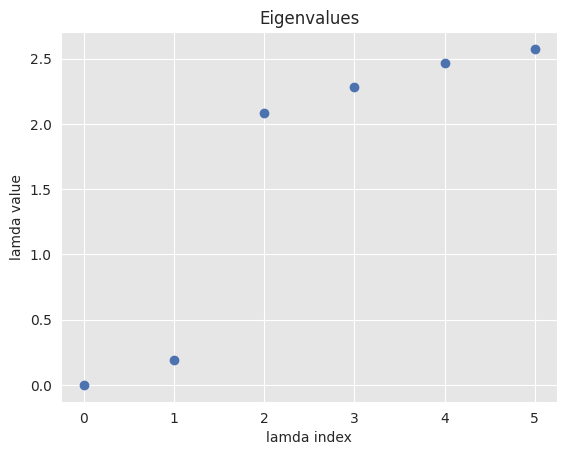

In [51]:
fig = pyplot.scatter(x,y)
pyplot.title("Eigenvalues")
pyplot.xlabel("lamda index")
pyplot.ylabel("lamda value")
pyplot.show()

In [52]:
eigenvals_index = np.argwhere(abs(eigenvals) < 2)
proj_df = pd.DataFrame(eigenvcts[:, eigenvals_index.squeeze()])
proj_df.columns = ['v_' + str(c) for c in proj_df.columns]
print(proj_df)

        v_0       v_1
0 -0.408248 -0.408401
1 -0.408248 -0.441825
2 -0.408248 -0.371319
3 -0.408248  0.371334
4 -0.408248  0.405048
5 -0.408248  0.445163


In [53]:
proj_df['No'] = np.arange(len(proj_df))
print(proj_df)

        v_0       v_1  No
0 -0.408248 -0.408401   0
1 -0.408248 -0.441825   1
2 -0.408248 -0.371319   2
3 -0.408248  0.371334   3
4 -0.408248  0.405048   4
5 -0.408248  0.445163   5


In [54]:
proj_df['No'] = np.arange(len(proj_df))
print(proj_df)

        v_0       v_1  No
0 -0.408248 -0.408401   0
1 -0.408248 -0.441825   1
2 -0.408248 -0.371319   2
3 -0.408248  0.371334   3
4 -0.408248  0.405048   4
5 -0.408248  0.445163   5


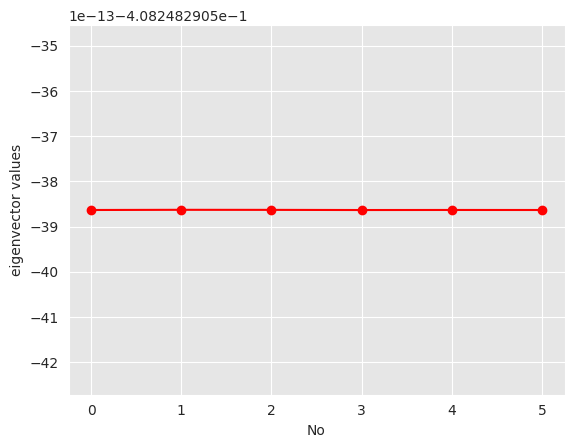

In [55]:
pyplot.plot(proj_df['No'], proj_df['v_0'], color='red', marker='o')
pyplot.xlabel('No')
pyplot.ylabel('eigenvector values')
pyplot.show()


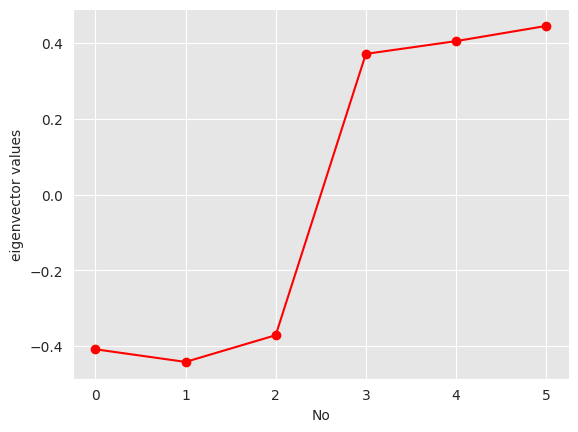

In [56]:
pyplot.plot(proj_df['No'], proj_df['v_1'], color='red', marker='o')
pyplot.xlabel('No')
pyplot.ylabel('eigenvector values')
pyplot.show()

###Iris data

In [58]:
## input data
raw_df = pd.read_csv('/content/Iris.csv')


In [59]:
raw_df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [60]:
raw_df.fillna(method ='ffill', inplace = True)

raw_df

/tmp/ipython-input-2863995005.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  raw_df.fillna(method ='ffill', inplace = True)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [61]:
## Create Laplacian matrix
from sklearn.neighbors import kneighbors_graph
from scipy import sparse

In [62]:
# numpy array
array = raw_df.to_numpy()
array

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [63]:
def generate_graph_laplacian(array, nn):
    """Generate graph Laplacian from data."""
    # Adjacency Matrix.
    connectivity = kneighbors_graph(X=array, n_neighbors=nn, mode='connectivity')
    adjacency_matrix_w = (1/2)*(connectivity + connectivity.T)
    # Graph Laplacian, normed=normalization.
    graph_laplacian_s = sparse.csgraph.laplacian(csgraph=adjacency_matrix_w, normed=False)
    graph_laplacian = graph_laplacian_s.toarray()
    return graph_laplacian

graph_laplacian = generate_graph_laplacian(array=array, nn=8)
print("Matrix Laplacian:")
print(graph_laplacian)

Matrix Laplacian:
[[10.5  0.   0.  ...  0.   0.   0. ]
 [ 0.   8.5 -0.5 ...  0.   0.   0. ]
 [ 0.  -0.5 10.  ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ... 11.  -0.5  0. ]
 [ 0.   0.   0.  ... -0.5  5.5  0. ]
 [ 0.   0.   0.  ...  0.   0.   8.5]]


In [64]:

## Compute eigenvectors and eigenvalues
from scipy import linalg

def compute_spectrum_graph_laplacian(graph_laplacian):
    """Compute eigenvalues and eigenvectors and project
    them onto the real numbers.
    """
    eigenvals, eigenvcts = linalg.eig(graph_laplacian)
    eigenvals = np.real(eigenvals)
    eigenvcts = np.real(eigenvcts)
    return eigenvals, eigenvcts

eigenvals, eigenvcts = compute_spectrum_graph_laplacian(graph_laplacian)
print("Eigenvalues Graph Laplacian:")
print(eigenvals)
print("Eigenvectors Graph Laplacian:")
print(eigenvcts)


Eigenvalues Graph Laplacian:
[-1.99840144e-15  3.93594872e-01  1.69269014e+00  2.57483887e+00
  1.38074796e+01  3.32466954e+00  3.43469649e+00  3.67425167e+00
  4.20047550e+00  4.56272017e+00  4.83802286e+00  1.33038663e+01
  1.30136886e+01  1.26757232e+01  1.27216218e+01  1.22222720e+01
  1.19739008e+01  1.17091139e+01  5.27416133e+00  5.52263890e+00
  5.80881539e+00  1.14858499e+01  1.13044974e+01  1.11773246e+01
  1.08152611e+01  1.06846783e+01  1.04710273e+01  1.02140990e+01
  6.15935020e+00  6.00369889e+00  7.07021665e+00  9.49765012e+00
  9.28221363e+00  8.35866965e+00  6.79074802e+00  7.50091961e+00
  6.68112794e+00  7.44032027e+00  9.98719074e+00  9.17249710e+00
  9.65974089e+00  9.60837730e+00  7.84396930e+00  8.88892062e+00
  8.50278052e+00  8.08110006e+00  7.87076716e+00  8.92300296e+00
  6.84907525e+00  6.94568368e+00  1.47117847e+01 -1.03984751e-16
  1.20652016e-01  3.99078525e-01  8.97591660e-01  9.86445388e-01
  1.65109306e+00  1.33936063e+01  2.30332224e+00  2.60698688e

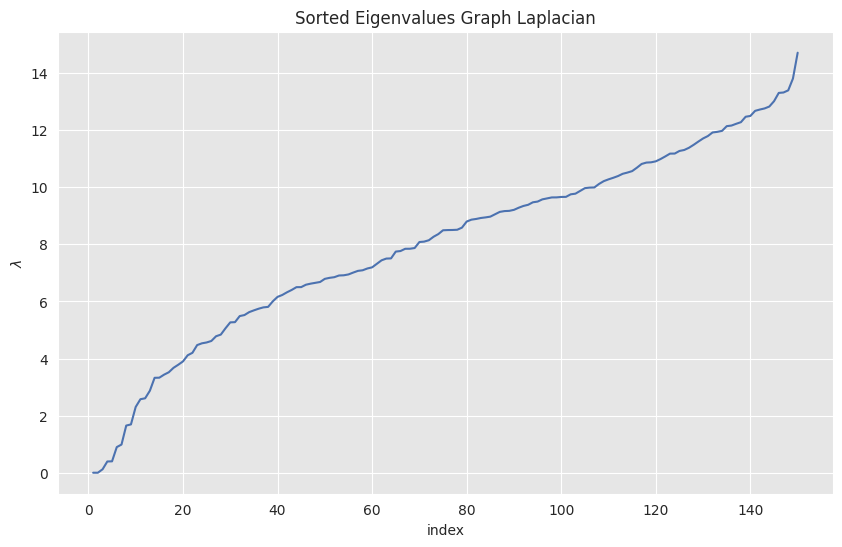

In [65]:
# Visualize
eigenvals_sorted_indices = np.argsort(eigenvals)
eigenvals_sorted = eigenvals[eigenvals_sorted_indices]
fig, ax = pyplot.subplots(figsize=(10, 6))
sns.lineplot(x=range(1, eigenvals_sorted_indices.size + 1), y=eigenvals_sorted, ax=ax)
ax.set(title='Sorted Eigenvalues Graph Laplacian', xlabel='index', ylabel=r'$\lambda$')
pyplot.show()

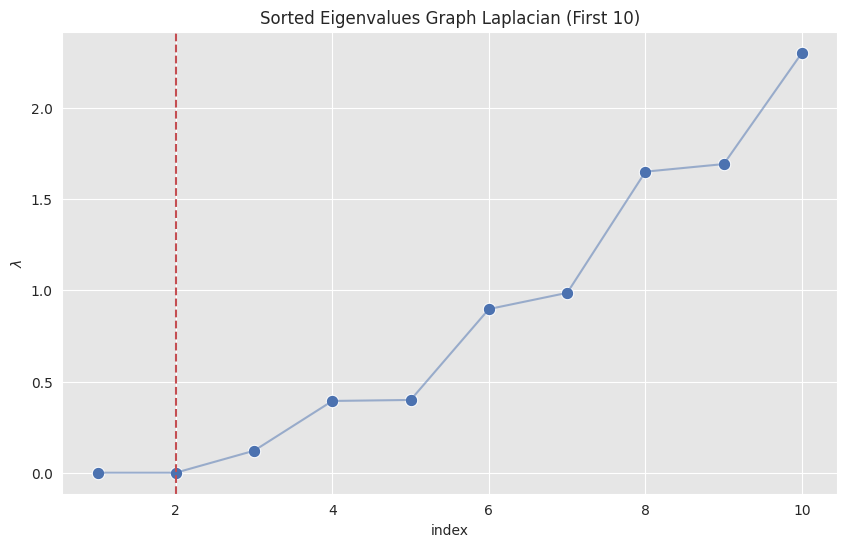

In [66]:
# Graph visualizes eigenvalues ~0.
# choose the first 10 indices from the eigenvalue graph above,
# we can clearly see which eigenvalues ~ 0 of the graph Laplacian.
index_lim = 10
fig, ax = pyplot.subplots(figsize=(10, 6))
sns.scatterplot(x=range(1, eigenvals_sorted_indices[: index_lim].size + 1), y=eigenvals_sorted[: index_lim], s=80, ax=ax)
sns.lineplot(x=range(1, eigenvals_sorted_indices[: index_lim].size + 1), y=eigenvals_sorted[: index_lim], alpha=0.5, ax=ax)
ax.axvline(x=2, color=sns_c[3], label='zero eigenvalues', linestyle='--')       # choose x
ax.set(title=f'Sorted Eigenvalues Graph Laplacian (First {index_lim})', xlabel='index', ylabel=r'$\lambda$')
pyplot.show()

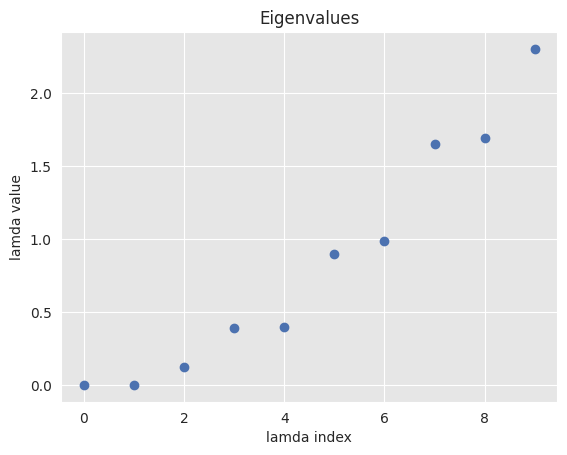

In [67]:
# choose k columns
y_total = eigenvals_sorted.tolist()
y = y_total[0:10]


x = list(range(10))


fig = pyplot.scatter(x,y)
pyplot.title("Eigenvalues")
pyplot.xlabel("lamda index")
pyplot.ylabel("lamda value")
pyplot.show()

In [68]:
proj_df = pd.DataFrame(eigenvcts[:, eigenvals_sorted_indices.squeeze()])
proj_df.columns = ['v_' + str(c) for c in proj_df.columns]
print(proj_df)

          v_0  v_1       v_2       v_3       v_4       v_5       v_6  \
0    0.141421  0.0  0.000000 -0.082139  0.000000  0.000000  0.000000   
1    0.141421  0.0  0.000000  0.160740  0.000000  0.000000  0.000000   
2    0.141421  0.0  0.000000  0.171519  0.000000  0.000000  0.000000   
3    0.141421  0.0  0.000000  0.182380  0.000000  0.000000  0.000000   
4    0.141421  0.0  0.000000 -0.088357  0.000000  0.000000  0.000000   
..        ...  ...       ...       ...       ...       ...       ...   
145  0.000000 -0.1 -0.109345  0.000000  0.009151  0.137922  0.101763   
146  0.000000 -0.1  0.005521  0.000000 -0.122772  0.063371 -0.123898   
147  0.000000 -0.1 -0.092532  0.000000 -0.012019  0.124035  0.091298   
148  0.000000 -0.1 -0.114791  0.000000  0.017012  0.142259  0.103744   
149  0.000000 -0.1  0.024145  0.000000 -0.139969  0.054180 -0.189190   

          v_7       v_8       v_9  ...     v_140     v_141     v_142  \
0    0.000000 -0.157072  0.000000  ... -0.182107 -0.016009  0.0

In [69]:

proj_df['No'] = np.arange(len(proj_df))
print(proj_df)

          v_0  v_1       v_2       v_3       v_4       v_5       v_6  \
0    0.141421  0.0  0.000000 -0.082139  0.000000  0.000000  0.000000   
1    0.141421  0.0  0.000000  0.160740  0.000000  0.000000  0.000000   
2    0.141421  0.0  0.000000  0.171519  0.000000  0.000000  0.000000   
3    0.141421  0.0  0.000000  0.182380  0.000000  0.000000  0.000000   
4    0.141421  0.0  0.000000 -0.088357  0.000000  0.000000  0.000000   
..        ...  ...       ...       ...       ...       ...       ...   
145  0.000000 -0.1 -0.109345  0.000000  0.009151  0.137922  0.101763   
146  0.000000 -0.1  0.005521  0.000000 -0.122772  0.063371 -0.123898   
147  0.000000 -0.1 -0.092532  0.000000 -0.012019  0.124035  0.091298   
148  0.000000 -0.1 -0.114791  0.000000  0.017012  0.142259  0.103744   
149  0.000000 -0.1  0.024145  0.000000 -0.139969  0.054180 -0.189190   

          v_7       v_8       v_9  ...     v_141     v_142     v_143  \
0    0.000000 -0.157072  0.000000  ... -0.016009  0.000000  0.0

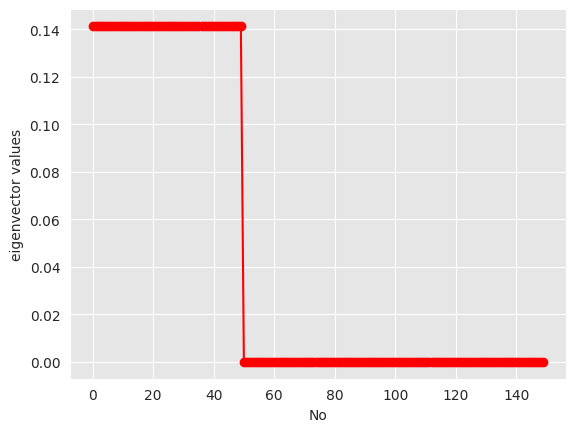

In [70]:
pyplot.plot(proj_df['No'], proj_df['v_0'], color='red', marker='o')
pyplot.xlabel('No')
pyplot.ylabel('eigenvector values')
pyplot.show()

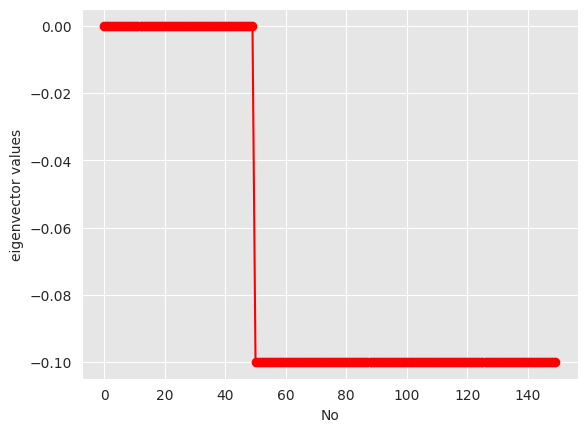

In [71]:
pyplot.plot(proj_df['No'], proj_df['v_1'], color='red', marker='o')
pyplot.xlabel('No')
pyplot.ylabel('eigenvector values')
pyplot.show()

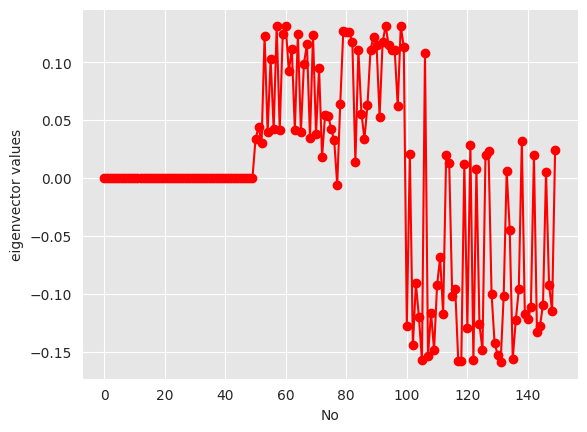

In [72]:
pyplot.plot(proj_df['No'], proj_df['v_2'], color='red', marker='o')
pyplot.xlabel('No')
pyplot.ylabel('eigenvector values')
pyplot.show()

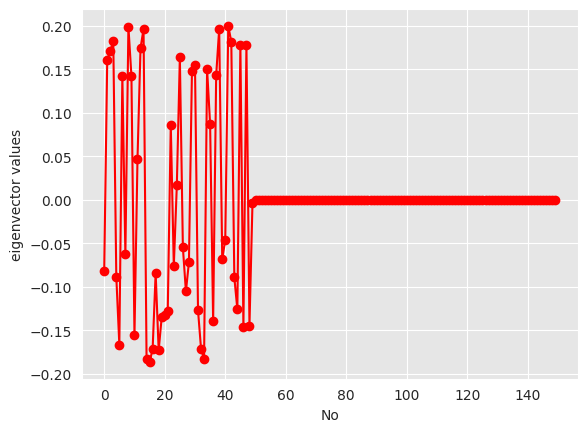

In [73]:
pyplot.plot(proj_df['No'], proj_df['v_3'], color='red', marker='o')
pyplot.xlabel('No')
pyplot.ylabel('eigenvector values')
pyplot.show()

In [74]:

# eigenvalues ~ 0
zero_eigenvals_index = np.argwhere(abs(eigenvals) < 1e-5)
eigenvals[zero_eigenvals_index]


array([[-1.99840144e-15],
       [-1.03984751e-16]])

In [75]:
# eigenvectors correspond to eigenvalues ~ 0
proj_df = pd.DataFrame(eigenvcts[:, zero_eigenvals_index.squeeze()])
proj_df.columns = ['v_' + str(c) for c in proj_df.columns]
print(proj_df)

          v_0  v_1
0    0.141421  0.0
1    0.141421  0.0
2    0.141421  0.0
3    0.141421  0.0
4    0.141421  0.0
..        ...  ...
145  0.000000 -0.1
146  0.000000 -0.1
147  0.000000 -0.1
148  0.000000 -0.1
149  0.000000 -0.1

[150 rows x 2 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


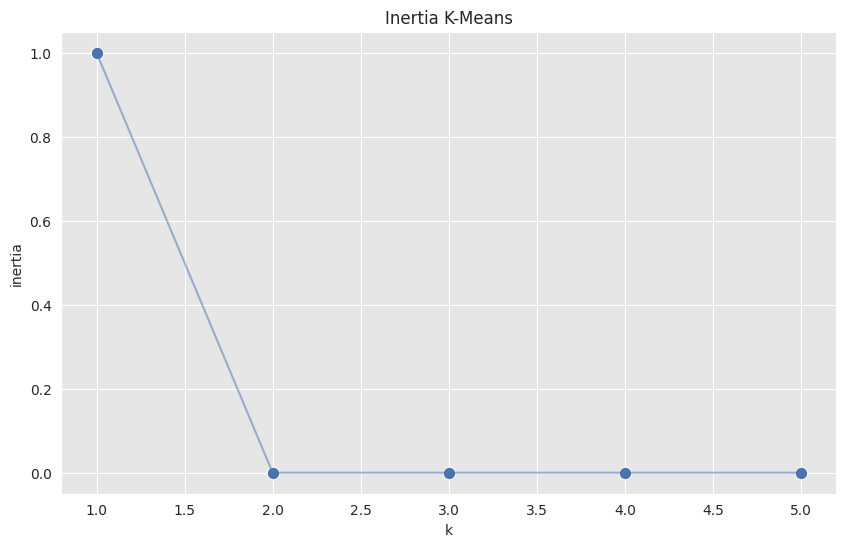

In [76]:
## run_k_means uses k-means to cluster based on eigenvectors above
# Run K-means clustering
inertias = []

k_candidates = range(1, 6)

for k in k_candidates:
    k_means = KMeans(random_state=42, n_clusters=k)
    k_means.fit(proj_df)
    inertias.append(k_means.inertia_)

fig, ax = pyplot.subplots(figsize=(10, 6))
sns.scatterplot(x=k_candidates, y = inertias, s=80, ax=ax)
sns.lineplot(x=k_candidates, y = inertias, alpha=0.5, ax=ax)
ax.set(title='Inertia K-Means', ylabel='inertia', xlabel='k')
pyplot.show()

In [77]:
def run_k_means(df, n_clusters):
    """K-means clustering."""
    k_means = KMeans(random_state=25, n_clusters=n_clusters)
    k_means.fit(df)
    cluster = k_means.predict(df)
    return cluster

cluster = run_k_means(proj_df, n_clusters=2)      # n_clusters=k

In [78]:
## visualize
# Reduce the dimensions
# StandardScaler() will normalize the features i.e. each column of X, INDIVIDUALLY,
# so that each column/feature/variable will have μ = 0 and σ = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(raw_df)
print(X_scaled)


[[-9.00681170e-01  1.03205722e+00 -1.34127240e+00 -1.31297673e+00]
 [-1.14301691e+00 -1.24957601e-01 -1.34127240e+00 -1.31297673e+00]
 [-1.38535265e+00  3.37848329e-01 -1.39813811e+00 -1.31297673e+00]
 [-1.50652052e+00  1.06445364e-01 -1.28440670e+00 -1.31297673e+00]
 [-1.02184904e+00  1.26346019e+00 -1.34127240e+00 -1.31297673e+00]
 [-5.37177559e-01  1.95766909e+00 -1.17067529e+00 -1.05003079e+00]
 [-1.50652052e+00  8.00654259e-01 -1.34127240e+00 -1.18150376e+00]
 [-1.02184904e+00  8.00654259e-01 -1.28440670e+00 -1.31297673e+00]
 [-1.74885626e+00 -3.56360566e-01 -1.34127240e+00 -1.31297673e+00]
 [-1.14301691e+00  1.06445364e-01 -1.28440670e+00 -1.44444970e+00]
 [-5.37177559e-01  1.49486315e+00 -1.28440670e+00 -1.31297673e+00]
 [-1.26418478e+00  8.00654259e-01 -1.22754100e+00 -1.31297673e+00]
 [-1.26418478e+00 -1.24957601e-01 -1.34127240e+00 -1.44444970e+00]
 [-1.87002413e+00 -1.24957601e-01 -1.51186952e+00 -1.44444970e+00]
 [-5.25060772e-02  2.18907205e+00 -1.45500381e+00 -1.31297673e

In [79]:
# Normalize
X_normalized = normalize(X_scaled)


# Converting the numpy array into a pandas DataFrame
X_normalized = pd.DataFrame(X_normalized)


# Reducing the dimensions of the data
pca = PCA(n_components = 2)
df = pca.fit_transform(X_normalized)
df = pd.DataFrame(df)
df.columns = ['P1', 'P2']


In [80]:

df['cluster'] = ['c_' + str(c) for c in cluster]

df

,P1,P2,cluster
0,-1.121912,0.267905,c_1
1,-1.080949,-0.242703,c_1
2,-1.126191,-0.084878,c_1
3,-1.100280,-0.194962,c_1
4,-1.109817,0.319559,c_1
...,...,...,...
145,0.804754,0.308406,c_0
146,0.730574,-0.385791,c_0
147,0.830357,0.280716,c_0
148,0.557988,0.609208,c_0


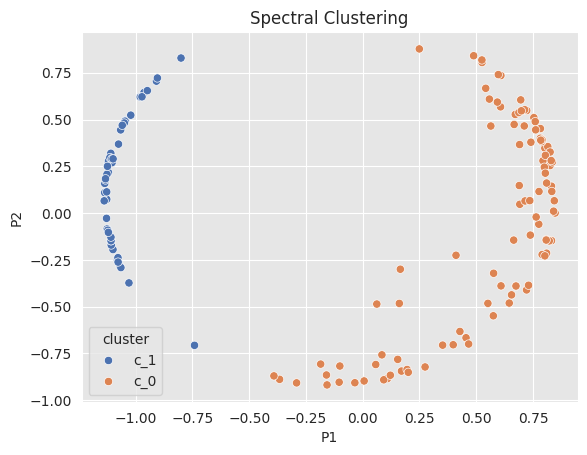

In [81]:
fig, ax = pyplot.subplots()
sns.scatterplot(x='P1', y='P2', data = df, hue='cluster', ax=ax)
ax.set(title='Spectral Clustering')
pyplot.show()